In [6]:
import ee
import math
import geemap
import pprint
import datetime
import pandas as pd
from tabulate import tabulate

ee.Authenticate
ee.Initialize(project='toribiodiego-ece471')

# Homework 2
- ECE471: Fundamentals of Remote Sensing and Earth Observation
- Spring 2025
- Instructor: Krishna Karra
- Contact: krishna.karra@cooper.edu (Teams chat is quickest)
- Assigned: Wednesday, February 26, 2025
- Due: Tuesday, March 18, 2025 (by midnight EST)

## Problem Motivation

The United States Department of Agriculture (USDA), in conjunction with the United States Geological Survey (USGS), produces the Cropland Data Layer (CDL), an annual landcover map of crop types across the Continental United States at 30-meter resolution. This map, which incorporates Landsat and Sentinel imagery from across the year, represents some of the highest quality, rigorously validated land cover classification that can be found anywhere.

A year's annual map is usually released a few months into the next year (e.g. the 2020 CDL is released towards the end of the first quarter of 2021). As a geospatial consultant, your task is to investigate whether certain crop types could be predicted *in-season* (e.g. without using a full year's worth of imagery).

The CDL is used within government and industry for crop health monitoring, crop area estimation, agricultural policy development, environmental monitoring, yield forecasting and more. In-season prediction of crop types would be vastly useful for all of these applications.

For this pilot study, the focus will be on Iowa and Illinois.

## Problem Overview

The overall workflow will be:

1. Analyze cropland data to identify the 5 most prevalent crops grown in Iowa and Illinois.
2. Explore and visualize the seasonal patterns of those 5 crops using vegetation index time series analysis.
3. Develop a crop identification model that takes satellite imagery as input and predicts crop type at the pixel level.
4. Assess model performance using validation data and metrics.
5. Apply the model to full counties to produce crop type maps and compare against ground truth data.

The core data sources will be:

1. Cropland Data Layer (CDL) for crop type ground truth labels
2. Landsat satellite imagery for model inputs
3. Google Earth Engine (GEE) platform for analysis and modeling

This assignment will give you real, concrete experience with:

- Working with large-scale geospatial data
- Time series analysis of vegetation indices
- Developing and validating a remote sensing model
- Creating meaningful data visualizations and maps

Your modeling approach and additional data sources are flexible. The key deliverables are: ranked crop list, crop seasonal analysis, trained crop identification model, model evaluations, and final county-level crop maps.

## Task 1: Identify Most Prevalent Crops

###*Goal: Plan to have made significant progress on Task 1 (or completed it) by March 5.*

The goal of this task is to create a ranked list of the most commonly grown crops across Iowa and Illinois based on acreage data from the 2019 Cropland Data Layer (CDL).

Specifically, you should:

1. Load the 2019 CDL raster data for the 2 states from Google Earth Engine.
2. Write a script to calculate the total acreage of each unique crop type in the CDL legend across the 2 states.
3. Rank the crops based on total acreage from most to least.
4. Output the list as a CSV file with two columns: Crop Name and Total Acres. Include the top 20 crops. Include the top 20 crops.
5. From this list, select the top 5 most prevalent crops. These will be the focus for the rest of the analysis.

Things to keep in mind:

1. Analysis must be done programmatically using GEE.
2. Output must be a clean CSV file with the columns specified.
3. Make sure to handle any data filtering or preprocessing steps like reprojections.
4. Document your methodology and thought process

### Helper Functions

In [7]:
def compute_crop_acreage_table(
    region,
    crop_legend,
    area_name=None,
    verbose=False,
    top5=False,
    global_stats=False,
    produce_top20_csv=False
):
    """
    Compute crop acreage statistics within the given region using the USDA NASS
    Cropland Data Layer (CDL) from 2019. Returns a formatted table (as string)
    that includes Rank, Crop Code, Crop Name, Total Acres, and % of total crop acres.

    Also calculates and displays global statistics (if global_stats=True) in a table
    with two columns:
      "# Unique Crops" and "Total Acres" (total region area, formatted with commas).

    If produce_top20_csv=True, saves a CSV containing the top 20 crops by acreage
    (with columns: Crop Name, Total Acres) to a file named:
        <area_name>_top20_crops.csv
    If area_name is not provided, defaults to "top20_crops.csv".

    Parameters:
    -----------
    region : ee.Geometry
        The area of interest.
    crop_legend : dict
        A dictionary mapping crop codes (int) to crop names (str).
    area_name : str, optional
        Name to embed in CSV file if produce_top20_csv=True.
    verbose : bool, optional
        If True, prints a table with all crops.
    top5 : bool, optional
        If True, prints a table with only the top 5 crops.
        (If verbose=True, overrides top5 and prints everything.)
    global_stats : bool, optional
        If True, prints out global statistics about the region’s acreage and cropping.
    produce_top20_csv : bool, optional
        If True, creates a CSV file with the top 20 crops, named by area_name if provided.

    Returns:
    --------
    table_str : str
        A formatted string table of the results.
    """

    # ----------------------------------------------------------------------
    # 1) Load the 2019 CDL image.
    # ----------------------------------------------------------------------
    cdl_2019 = ee.Image('USDA/NASS/CDL/2019')

    # ----------------------------------------------------------------------
    # 2) Calculate total area in the region (for global statistics).
    #    Using a separate reduction over an area-only image.
    # ----------------------------------------------------------------------
    # Each pixel is 30 m x 30 m => 900 m^2
    # We'll convert area to acres by multiplying with 0.000247105.
    area_image = ee.Image.pixelArea().multiply(0.000247105)  # in acres

    total_area_stats = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=30,
        maxPixels=1e13
    )
    # Total region area in acres
    total_area_in_acres = total_area_stats.getInfo().get('area', 0)

    # ----------------------------------------------------------------------
    # 3) Build an image that has:
    #    - Band 0: Pixel area in acres
    #    - Band 1: The 2019 CDL "cropland" band (crop code)
    # ----------------------------------------------------------------------
    combined_image = area_image.addBands(cdl_2019.select('cropland'))

    # ----------------------------------------------------------------------
    # 4) Reduce the image over the region, summing area by crop code.
    # ----------------------------------------------------------------------
    reducer = ee.Reducer.sum().group(
        groupField=1,       # The second band (index=1) is the crop code
        groupName='crop_code'
    )

    stats = combined_image.reduceRegion(
        reducer=reducer,
        geometry=region,
        scale=30,
        maxPixels=1e13
    )

    groups = stats.get('groups')
    if groups is None:
        # No crops found in this region
        return "No crop data found for this region."

    groups = groups.getInfo()  # Convert to Python list

    # ----------------------------------------------------------------------
    # 5) Prepare the table data (per-crop) and gather for global stats.
    # ----------------------------------------------------------------------
    table_data = []
    total_crop_acres = 0.0

    for entry in groups:
        acreage = entry['sum']
        total_crop_acres += acreage

    for entry in groups:
        crop_code = entry['crop_code']
        acreage = entry['sum']
        crop_name = crop_legend.get(crop_code, "Unknown")
        # Compute % of total crop area
        pct_crops = (acreage / total_crop_acres) * 100 if total_crop_acres else 0
        table_data.append({
            "Code": crop_code,
            "Name": crop_name,
            "Total": round(acreage),  # kept as number for CSV export
            "Area (%)": round(pct_crops)
        })

    # Sort by Total Acres descending
    table_data_sorted = sorted(table_data, key=lambda x: x["Total"], reverse=True)

    # ----------------------------------------------------------------------
    # 6) Add a rank column
    # ----------------------------------------------------------------------
    for idx, row in enumerate(table_data_sorted, start=1):
        row["Rank"] = idx

    # Reorder columns for final output (keeping numeric values for CSV)
    final_data = []
    for row in table_data_sorted:
        final_data.append({
            "Rank": row["Rank"],
            "Code": row["Code"],
            "Name": row["Name"],
            "Total": row["Total"],
            "%": row["Area (%)"]
        })

    # Create a display copy of the data with comma formatting for "Total Acres"
    # and filter out unwanted word from the crop name for printing
    display_data = []
    for row in final_data:
        new_row = row.copy()
        new_row["Total"] = format(row["Total"], ",")
        # Filter out the words "Intensity" and "Space" in the displayed name.
        for word in ["Intensity", "Space"]:
            new_row["Name"] = new_row["Name"].replace(word, "")
        new_row["Name"] = new_row["Name"].strip()
        display_data.append(new_row)


    # ----------------------------------------------------------------------
    # 7) Handle the printing based on verbose/top5 flags
    # ----------------------------------------------------------------------
    if verbose:
        # Print ALL
        data_to_print = display_data
    elif top5:
        # Print ONLY top 5
        data_to_print = display_data[:5]
    else:
        # Default: print all
        data_to_print = display_data

    table_str = tabulate(data_to_print, headers="keys", tablefmt="grid")

    # ----------------------------------------------------------------------
    # 8) Global statistics (if requested) in a two-column table.
    #    Here we show:
    #      "# Unique Crops": number of unique crops
    #      "Total Acres": total region area (with comma formatting)
    # ----------------------------------------------------------------------
    if global_stats:
        unique_crops = len(final_data)
        global_stats_data = [{
            "# Unique Crops": unique_crops,
            "Total Area": format(round(total_area_in_acres), ",")
        }]
        global_stats_table = tabulate(global_stats_data, headers="keys", tablefmt="grid")
        table_str = table_str + "\n" + global_stats_table

    # ----------------------------------------------------------------------
    # 9) If requested, produce a CSV with top 20 crops (without comma formatting)
    # ----------------------------------------------------------------------
    if produce_top20_csv:
        # If area_name is given, build the CSV name from it
        if area_name:
            csv_filename = f"{area_name}_top20_crops.csv"
        else:
            csv_filename = "top20_crops.csv"

        df = pd.DataFrame(final_data)
        df_top20 = df.sort_values(by="Total", ascending=False).head(20)
        # For CSV, only keep "Crop Name" and "Total Acres" (no comma formatting)
        df_top20 = df_top20[["Name", "Total"]]
        df_top20.to_csv(csv_filename, index=False)
        print(f"[INFO] CSV file saved as: {csv_filename}")

    return table_str


def get_state_geometry(state_abbr_list):
    """
    Given a list of state abbreviations (e.g. ['IA', 'IL']), returns a combined ee.Geometry
    for those states using the TIGER/2018/States collection.
    """
    states = ee.FeatureCollection('TIGER/2018/States')
    fc_filtered = states.filter(ee.Filter.inList('STUSPS', state_abbr_list))
    return fc_filtered.geometry()


def get_county_geometry(state_fips, county_name):
    """
    Retrieve the ee.Geometry for a given county using its state FIPS code and county name.
    """
    counties = ee.FeatureCollection("TIGER/2018/Counties")
    county_fc = counties.filter(ee.Filter.eq('STATEFP', state_fips)) \
                        .filter(ee.Filter.eq('NAME', county_name))
    return county_fc.first().geometry()


def get_county_spread(state_fips):
    """
    Returns (smallest_county, median_county, largest_county) for a given state (by FIPS code).
    Also prints a small table (using tabulate) showing county name and acreage
    for the smallest, median, and largest counties, with acreage formatted with commas.
    """
    counties = ee.FeatureCollection("TIGER/2018/Counties").filter(
        ee.Filter.eq('STATEFP', state_fips)
    )

    # Pull data client-side
    counties_info = counties.getInfo()['features']
    sqm_to_acres = 0.000247105

    # Collect (county_name, land_area_in_acres) for sorting
    county_land_area = []
    for f in counties_info:
        props = f['properties']
        name = props['NAME']
        acres = props['ALAND'] * sqm_to_acres
        county_land_area.append((name, round(acres)))

    # Sort ascending by acreage
    county_land_area.sort(key=lambda x: x[1])

    # Identify smallest, median, largest
    smallest = county_land_area[0]
    largest = county_land_area[-1]
    mid_idx = len(county_land_area) // 2
    median = county_land_area[mid_idx]  # if even, this picks the higher middle

    # Prepare table with smallest, median, largest.
    # Format acreage with commas for human readability.
    spread_data = [
        {"Type": "Smallest", "County Name": smallest[0], "Acreage": format(smallest[1], ",")},
        {"Type": "Median",   "County Name": median[0],   "Acreage": format(median[1], ",")},
        {"Type": "Largest",  "County Name": largest[0],  "Acreage": format(largest[1], ",")},
    ]
    print(tabulate(spread_data, headers="keys", tablefmt="grid"))

    return smallest, median, largest

### 1.1 - Simple Rectangular Region

In [ ]:
# define a small rectangular geometry (e.g., in Central Iowa)
test_region = ee.Geometry.Rectangle([-93.75, 41.6, -93.6, 41.7])

# load the 2019 CDL image and build a crop legend
cdl_2019 = ee.Image('USDA/NASS/CDL/2019')

crop_class_names = cdl_2019.get('cropland_class_names').getInfo()
crop_class_values = cdl_2019.get('cropland_class_values').getInfo()

# if properties are strings, convert them to lists
if isinstance(crop_class_names, str):
    crop_class_names = crop_class_names.split(',')

if isinstance(crop_class_values, str):
    crop_class_values = [int(val) for val in crop_class_values.split(',')]

crop_legend = dict(zip(crop_class_values, crop_class_names))


\
# compute the crop acreage table for the test region
table_str = compute_crop_acreage_table(
    region=test_region,
    crop_legend=crop_legend,
    area_name="test_rectangle",
    verbose=False,
    top5=True,           # print top 5
    global_stats=True,   # print global statistics
    produce_top20_csv=False
)


print(table_str)
print("\n\033[1mTable 1\033[0m. Crop Acreage Table (top 5) with global statistics for the small test region (Central Iowa).")

+--------+--------+----------------+---------+-----+
|   Rank |   Code | Name           | Total   |   % |
+========+========+================+=========+=====+
|      1 |    122 | Developed/Low  | 11,224  |  33 |
+--------+--------+----------------+---------+-----+
|      2 |    121 | Developed/Open | 6,810   |  20 |
+--------+--------+----------------+---------+-----+
|      3 |    123 | Developed/Med  | 3,931   |  11 |
+--------+--------+----------------+---------+-----+
|      4 |    190 | Woody Wetlands | 2,124   |   6 |
+--------+--------+----------------+---------+-----+
|      5 |    176 | Grass/Pasture  | 2,032   |   6 |
+--------+--------+----------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               24 | 34,299       |
+------------------+--------------+

Table 1. Crop Acreage Table (top 5) with global statistics for the small test region (Central Iowa).


### 1.2 - Iowa County Spread

In [ ]:
# get the smallest, median, and largest counties by land area.
smallest_county, median_county, largest_county = get_county_spread(state_fips='19') # Iowa's state FIPS code is '19'.

# retrieve the geometries for each.
smallest_geom = get_county_geometry('19', smallest_county[0])
median_geom = get_county_geometry('19', median_county[0])
largest_geom = get_county_geometry('19', largest_county[0])

#### 1.2.1 - Smallest County

In [ ]:
table_small = compute_crop_acreage_table(
    region=smallest_geom,
    crop_legend=crop_legend,
    area_name="Iowa_smallest_county",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=False
)
print(table_small)
print("\n\033[1mTable 2\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa's smallest county (Dickinson).")

+--------+--------+---------------------+---------+-----+
|   Rank |   Code | Name                | Total   |   % |
+========+========+=====================+=========+=====+
|      1 |      1 | Corn                | 94,176  |  36 |
+--------+--------+---------------------+---------+-----+
|      2 |      5 | Soybeans            | 76,273  |  30 |
+--------+--------+---------------------+---------+-----+
|      3 |    176 | Grass/Pasture       | 25,505  |  10 |
+--------+--------+---------------------+---------+-----+
|      4 |    195 | Herbaceous Wetlands | 17,314  |   7 |
+--------+--------+---------------------+---------+-----+
|      5 |    111 | Open Water          | 15,564  |   6 |
+--------+--------+---------------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               30 | 258,535      |
+------------------+--------------+

Table 2. Crop Acreage Table (top 5) with global statistics for Io

#### 1.2.2 - Median County

In [ ]:
table_median = compute_crop_acreage_table(
    region=median_geom,
    crop_legend=crop_legend,
    area_name="Iowa_median_county",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=False
)
print(table_median)
print("\n\033[1mTable 3\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa's median county (Greene).")

+--------+--------+------------------+---------+-----+
|   Rank |   Code | Name             | Total   |   % |
+========+========+==================+=========+=====+
|      1 |      1 | Corn             | 177,537 |  49 |
+--------+--------+------------------+---------+-----+
|      2 |      5 | Soybeans         | 120,595 |  33 |
+--------+--------+------------------+---------+-----+
|      3 |    176 | Grass/Pasture    | 23,398  |   6 |
+--------+--------+------------------+---------+-----+
|      4 |    121 | Developed/Open   | 13,267  |   4 |
+--------+--------+------------------+---------+-----+
|      5 |    141 | Deciduous Forest | 11,484  |   3 |
+--------+--------+------------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               28 | 365,611      |
+------------------+--------------+

Table 3. Crop Acreage Table (top 5) with global statistics for Iowa's median county (Greene).


#### 1.2.3 - Largest County

In [ ]:
table_large = compute_crop_acreage_table(
    region=largest_geom,
    crop_legend=crop_legend,
    area_name="Iowa_largest_county",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=False
)
print(table_large)
print("\n\033[1mTable 4\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa's largest county (Kossuth).")

+--------+--------+---------------------+---------+-----+
|   Rank |   Code | Name                | Total   |   % |
+========+========+=====================+=========+=====+
|      1 |      1 | Corn                | 317,292 |  51 |
+--------+--------+---------------------+---------+-----+
|      2 |      5 | Soybeans            | 205,863 |  33 |
+--------+--------+---------------------+---------+-----+
|      3 |    176 | Grass/Pasture       | 32,508  |   5 |
+--------+--------+---------------------+---------+-----+
|      4 |    121 | Developed/Open      | 21,438  |   3 |
+--------+--------+---------------------+---------+-----+
|      5 |    195 | Herbaceous Wetlands | 14,077  |   2 |
+--------+--------+---------------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               31 | 623,565      |
+------------------+--------------+

Table 4. Crop Acreage Table (top 5) with global statistics for Io

### 1.3 - Iowa and Illinois

In [ ]:
# create a combined geometry for Iowa + Illinois
ia_il_geometry = get_state_geometry(['IA', 'IL'])

# demonstrates producing a CSV with top 20 crops (useful for Task 1).
table_ia_il = compute_crop_acreage_table(
    region=ia_il_geometry,
    crop_legend=crop_legend,
    area_name="Iowa_Illinois",      # name the CSV "Iowa_Illinois_top20_crops.csv"
    verbose=False,                  # do not print every crop
    top5=True,                      # limit to top 5
    global_stats=True,              # print region-level stats
    produce_top20_csv=True          # generate CSV of top 20 crops
)
print(table_ia_il)
print("\n\033[1mTable 5\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa + Illinois.")

[INFO] CSV file saved as: Iowa_Illinois_top20_crops.csv
+--------+--------+------------------+------------+-----+
|   Rank |   Code | Name             | Total      |   % |
+========+========+==================+============+=====+
|      1 |      1 | Corn             | 24,044,494 |  33 |
+--------+--------+------------------+------------+-----+
|      2 |      5 | Soybeans         | 18,860,571 |  26 |
+--------+--------+------------------+------------+-----+
|      3 |    141 | Deciduous Forest | 7,935,511  |  11 |
+--------+--------+------------------+------------+-----+
|      4 |    176 | Grass/Pasture    | 7,378,873  |  10 |
+--------+--------+------------------+------------+-----+
|      5 |    121 | Developed/Open   | 2,690,743  |   4 |
+--------+--------+------------------+------------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               66 | 73,078,611   |
+------------------+--------------+

Table 5. 

## Task 2: Crop Seasonal Analysis

###*Goal: Plan to have made significant progress by March 5*

Goal: Analyze the seasonal patterns of the top 5 crops using vegetation index time series.

Overview:

1. Sample pixels growing for each crop across the two states
2. Compute NDVI time series for each crop sample
3. Generate visualizations of the NDVI curves
4. Perform additional analysis on crop emergence, harvest dates, etc (optional)

This will reveal unique temporal signatures of the crops and inform model development.

### Task 2.1: Sample Crop Pixel Locations

- Write a script to randomly sample at least 250 pixel locations for each of the 5 crops.
- Spread the sampling across the 2 states to capture geographical diversity.
- Output the sampled points as a FeatureCollection in GEE.
- Visualize the points to ensure they look as expected.
- Document your sampling methodology (e.g. spatial filters, randomization, etc.)
- The sampling script should be modular to allow increasing the sampling size.

#### 2.1.1 - Helper Functions

In [10]:
# 2.1) Grid Creation and Crop Sampling
def create_grid(region, cell_size):
    """
    Create a grid of square cells (as Features) covering the given region.
    :param region: ee.Geometry defining the region.
    :param cell_size: cell size in meters.
    :return: ee.FeatureCollection of grid cells.
    """
    bounds = region.bounds()
    coords = ee.List(ee.List(bounds.coordinates().get(0)))
    lons = coords.map(lambda pt: ee.Number(ee.List(pt).get(0)))
    lats = coords.map(lambda pt: ee.Number(ee.List(pt).get(1)))
    min_lon = ee.Number(lons.reduce(ee.Reducer.min()))
    max_lon = ee.Number(lons.reduce(ee.Reducer.max()))
    min_lat = ee.Number(lats.reduce(ee.Reducer.min()))
    max_lat = ee.Number(lats.reduce(ee.Reducer.max()))

    # Approx degrees for cell_size (1 deg ~ 111 km)
    cell_deg = ee.Number(cell_size).divide(111000)

    # Create lists of lon/lat values for grid lines
    lon_list = ee.List.sequence(min_lon, max_lon, cell_deg)
    lat_list = ee.List.sequence(min_lat, max_lat, cell_deg)

    def make_cell(lon):
        def make_cell_inner(lat):
            cell = ee.Geometry.Rectangle([
                lon, lat,
                ee.Number(lon).add(cell_deg),
                ee.Number(lat).add(cell_deg)
            ])
            return ee.Feature(cell)
        return lat_list.map(make_cell_inner)

    grid = lon_list.map(make_cell)
    grid = ee.FeatureCollection(ee.List(grid).flatten())
    return grid

def sample_crop_locations(cdl_image, crop_code, crop_name,
                          region_geom, num_points=250,
                          method='random', grid_size=50000):
    """
    Samples pixel locations for a given crop code using different sampling methods.
    """
    masked_crop = cdl_image.updateMask(cdl_image.eq(crop_code))

    if method == 'random':
        sample_fc = masked_crop.sample(
            region=region_geom,
            scale=30,
            numPixels=num_points,
            geometries=True,
            seed=42
        )
    elif method == 'stratified':
        grid = create_grid(region_geom, grid_size)
        grid_count = ee.Number(grid.size())
        points_per_cell = ee.Number(num_points).divide(grid_count).round().max(1)
        def sample_in_cell(cell):
            cell_geom = cell.geometry()
            cell_sample = masked_crop.sample(
                region=cell_geom,
                scale=30,
                numPixels=points_per_cell,
                geometries=True,
                seed=42
            )
            return cell_sample
        sample_fc = grid.map(sample_in_cell).flatten()
    elif method == 'systematic':
        grid = create_grid(region_geom, grid_size)
        centroids = grid.map(lambda f: ee.Feature(f.geometry().centroid()))
        def point_in_crop(pt):
            val = masked_crop.reduceRegion(
                reducer=ee.Reducer.first(),
                geometry=pt.geometry(),
                scale=30
            ).get('cropland')
            return ee.Algorithms.IsEqual(val, val)
        systematic_points = centroids.filter(point_in_crop)
        sample_fc = systematic_points.limit(num_points, 'systematic')
    elif method in ['cluster', 'adaptive']:
        print("Warning: {} sampling not fully implemented; falling back to random sampling.".format(method))
        sample_fc = masked_crop.sample(
            region=region_geom,
            scale=30,
            numPixels=num_points,
            geometries=True,
            seed=42
        )
    else:
        raise ValueError("Unknown sampling method: {}".format(method))

    return sample_fc.map(lambda f: f.set({"crop_code": crop_code, "crop_name": crop_name}))


#### 2.1

In [ ]:
top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space"
}

#### 2.1.1 Small Fix Region

In [ ]:
# (4) Test on small test region with just one crop
test_crop_code = 1   # let's pick "Corn" for example
test_crop_name = "Corn"

# We'll only sample 10 points in the small region, just to confirm everything runs
test_sample_fc = sample_crop_locations(
    cdl_image=cdl_2019,
    crop_code=test_crop_code,
    crop_name=test_crop_name,
    region_geom=test_region,
    num_points=10
)

print("Sample size for test region:", test_sample_fc.size().getInfo())
print("A few sample points (client-side dict):")
print(test_sample_fc.limit(3).getInfo())


Sample size for test region: 0
A few sample points (client-side dict):
{'type': 'FeatureCollection', 'columns': {'confidence': 'Short<0, 255>', 'crop_code': 'Integer', 'crop_name': 'String', 'cropland': 'Short<0, 255>', 'cultivated': 'Short<0, 255>'}, 'properties': {'band_order': ['cropland', 'cultivated', 'confidence']}, 'features': []}


#### 2.1.2 Counties

In [ ]:
# (4) Test on small test region with just one crop
test_crop_code = 1   # let's pick "Corn" for example
test_crop_name = "Corn"

# We'll only sample 10 points in the small region, just to confirm everything runs
test_sample_fc = sample_crop_locations(
    cdl_image=cdl_2019,
    crop_code=test_crop_code,
    crop_name=test_crop_name,
    region_geom=largest_geom,
    num_points=10
)

print("Sample size for test region:", test_sample_fc.size().getInfo())
print("A few sample points (client-side dict):")
print(test_sample_fc.limit(3).getInfo())

Sample size for test region: 0
A few sample points (client-side dict):
{'type': 'FeatureCollection', 'columns': {'confidence': 'Short<0, 255>', 'crop_code': 'Integer', 'crop_name': 'String', 'cropland': 'Short<0, 255>', 'cultivated': 'Short<0, 255>'}, 'properties': {'band_order': ['cropland', 'cultivated', 'confidence']}, 'features': []}


### 2.1.3 - Iowa and Illinois

In [ ]:
# (6) Generate final sample for the 5 crops across Iowa + Illinois
# We'll do 250 points per crop, as required.
all_samples = ee.FeatureCollection([])

for crop_code, crop_name in top_5_crops.items():
    crop_samples = sample_crop_locations(
        cdl_image=cdl_2019,
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=states_geometry,
        num_points=250
    )
    all_samples = all_samples.merge(crop_samples)

print("Total sample size across all 5 crops:", all_samples.size().getInfo())

Total sample size across all 5 crops: 0


In [ ]:
# Visualization parameters for the single band.
cdl_vis = {
    'min': 0,
    'max': 255,
    'palette': ['red', 'blue', 'green', 'cyan', 'magenta', 'yellow']
}


# Clip the 'cropland' band to the Iowa+Illinois geometry.
cdl_cropland = cdl_2019.select('cropland').clip(states_geometry)

# Create a map centered on roughly the Iowa/Illinois region.
m1 = geemap.Map(center=[41.6, -93.6], zoom=6)

# Add the clipped CDL layer to the map.
m1.addLayer(cdl_cropland, cdl_vis, "CDL 2019")

# Add the sampled points (which are already from Iowa + Illinois).
m1.addLayer(all_samples.draw(color='black', pointRadius=4), {}, "Sample Points")

m1

Map(center=[41.6, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

### Task 2.2: Calculate NDVI Time Series

- For each crop, use the sampled points to extract NDVI values over a full year.
- Use all available Landsat surface reflectance imagery from 2019.
- Handle clouds/shadows by filtering out low quality NDVI values.
- Calculate the mean, 1-sigma, and 2-sigma NDVI curves for each crop across the time series.
- Plot the NDVI curves with date on x-axis and NDVI on y-axis.
- Include the crop name, number of sample points, and time range in the plot.
- Document your approach for filtering, aggregating, and plotting the time series data.

Key requirements:

- Use GEE reducers to extract NDVI values per pixel.
- Make sure to mask clouds and filter low quality NDVI.
- Plot mean, 1-sigma, and 2-sigma to show variability across many samples
- Output clean, labeled, and informative plots.

In [2]:
# 2.2) Landsat NDVI Processing
def mask_landsat_clouds_sr(image):
    """
    Mask clouds, shadows, snow, and water in Landsat Collection 2 SR data (QA_PIXEL band).
    """
    qa_pixel = image.select('QA_PIXEL')
    cloud_bit = 1 << 3
    shadow_bit = 1 << 4
    snow_bit = 1 << 5
    water_bit = 1 << 7
    mask = (qa_pixel.bitwiseAnd(cloud_bit).eq(0)
            .And(qa_pixel.bitwiseAnd(shadow_bit).eq(0))
            .And(qa_pixel.bitwiseAnd(snow_bit).eq(0))
            .And(qa_pixel.bitwiseAnd(water_bit).eq(0)))
    return image.updateMask(mask)

def add_ndvi(image):
    """
    Compute NDVI = (NIR - RED) / (NIR + RED) for Landsat 8/9 SR.
    Band naming for L8/9 C2:
        RED = 'SR_B4', NIR = 'SR_B5'
    """
    ndvi = image.expression(
        '(NIR - RED) / (NIR + RED)',
        {
            'NIR': image.select('SR_B5').multiply(0.0000275).add(-0.2),
            'RED': image.select('SR_B4').multiply(0.0000275).add(-0.2),
        }
    ).rename('NDVI')
    return image.addBands(ndvi)

def get_landsat_ndvi_collection(start_date='2019-01-01',
                                end_date='2019-12-31',
                                region=None):
    """
    Returns a Landsat 8 SR Collection 2, filtered by date/region,
    with cloud masking and NDVI band added.
    """
    l8_sr = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
             .filterDate(start_date, end_date))
    if region:
        l8_sr = l8_sr.filterBounds(region)
    l8_sr = l8_sr.map(mask_landsat_clouds_sr).map(add_ndvi)
    # Keep NDVI band (and QA if desired).
    return l8_sr.select(["NDVI", "QA_PIXEL"])

def extract_ndvi_time_series(ndvi_collection, sample_points):
    """
    For each image in ndvi_collection, sample the NDVI value at each point.
    Returns a FeatureCollection with 'NDVI' and 'date' for each sample.
    """
    def per_image(image):
        date_str = image.date().format('YYYY-MM-dd')
        sampled = image.select("NDVI").sampleRegions(
            collection=sample_points,
            scale=30,
            geometries=True
        ).map(lambda f: f.set("date", date_str))
        return sampled
    return ndvi_collection.map(per_image).flatten()

def aggregate_ndvi_by_date(timeseries_fc):
    """
    Converts the FeatureCollection to a list, then groups by date
    to compute mean NDVI, std dev, count, etc. Returns a list of dicts:
      [
        {'date': 'YYYY-MM-DD',
         'mean_ndvi': ...,
         'std_dev': ...,
         'count': ...},
        ...
      ]
    """
    fc_list = timeseries_fc.toList(timeseries_fc.size()).getInfo()
    from collections import defaultdict
    from statistics import mean, pstdev

    data_by_date = defaultdict(list)
    for feat in fc_list:
        props = feat['properties']
        date_str = props.get('date')
        ndvi_val = props.get('NDVI')
        if date_str is not None and ndvi_val is not None:
            data_by_date[date_str].append(ndvi_val)

    results = []
    for date_str, ndvi_vals in data_by_date.items():
        if len(ndvi_vals) < 1:
            continue
        mean_ndvi = mean(ndvi_vals)
        std_dev = pstdev(ndvi_vals)  # population standard deviation
        results.append({
            'date': date_str,
            'mean_ndvi': mean_ndvi,
            'std_dev': std_dev,
            'count': len(ndvi_vals)
        })

    results.sort(key=lambda x: x['date'])
    return results

def plot_ndvi_time_series(ndvi_stats, title="NDVI Time Series"):
    """
    Plots NDVI time series with ±1σ and ±2σ shading.
    """
    if len(ndvi_stats) == 0:
        print("No NDVI data to plot.")
        return

    dates = [datetime.strptime(e['date'], '%Y-%m-%d') for e in ndvi_stats]
    means = [e['mean_ndvi'] for e in ndvi_stats]
    stdevs = [e['std_dev'] for e in ndvi_stats]

    plus_1sigma = [m + s for m, s in zip(means, stdevs)]
    minus_1sigma = [m - s for m, s in zip(means, stdevs)]
    plus_2sigma = [m + 2*s for m, s in zip(means, stdevs)]
    minus_2sigma = [m - 2*s for m, s in zip(means, stdevs)]

    plt.figure(figsize=(8, 5))
    plt.fill_between(dates, minus_2sigma, plus_2sigma, alpha=0.1, label='±2σ')
    plt.fill_between(dates, minus_1sigma, plus_1sigma, alpha=0.2, label='±1σ')
    plt.plot(dates, means, label='Mean NDVI')

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('NDVI')
    plt.legend()
    plt.grid(True)
    plt.show()


#### Extract NDVI Time Series at Sample Points

In [3]:
def analyze_county_ndvi(county_name, state_fips,
                        start_date='2019-01-01',
                        end_date='2019-12-31',
                        num_points=200):
    """
    Builds and plots the NDVI time series for the specified county.
      - Retrieves the county geometry
      - Filters Landsat NDVI for the date range
      - Randomly samples N points in the county
      - Extracts NDVI time series, aggregates, and prints/plots
    """
    # 1) Retrieve county geometry
    geom = get_county_geometry(state_fips, county_name)
    if geom is None:
        print(f"[Warning] Geometry is None for {county_name}, skipping.")
        return

    # 2) Build NDVI collection for date range
    ndvi_coll = get_landsat_ndvi_collection(start_date, end_date, geom)

    # 3) Sample the county geometry (randomly). If you want to do full-county means,
    #    you'd set up a different approach (e.g., reduceRegion over each date).
    #    Here, we do random sampling for demonstration.
    #    We'll just sample from the entire area, ignoring crop codes.
    #    So we'll create a dummy "crop_code" to reuse the function:
    cdl_dummy = ee.Image(1).rename("cropland").clip(geom)
    sample_fc = sample_crop_locations(
        cdl_image=cdl_dummy,
        crop_code=1,
        crop_name="county_random",
        region_geom=geom,
        num_points=num_points,
        method='random'
    )

    # 4) Extract NDVI time series
    ts_fc = extract_ndvi_time_series(ndvi_coll, sample_fc)

    # 5) Aggregate NDVI by date
    agg_data = aggregate_ndvi_by_date(ts_fc)

    # 6) Print the NDVI stats by date
    if len(agg_data) == 0:
        print(f"[Info] No NDVI data found for {county_name} in {start_date} - {end_date}.")
        return

    # Format for tabulate
    table_rows = []
    for row in agg_data:
        date_str = row['date']
        mean_val = row['mean_ndvi']
        std_val = row['std_dev']
        count_val = row['count']
        table_rows.append({
            "Date": date_str,
            "Mean NDVI": f"{mean_val:.4f}",
            "Std Dev":  f"{std_val:.4f}",
            "Count": count_val
        })

    print(f"\n=== NDVI Time Series for {county_name} ===")
    print(tabulate(table_rows, headers="keys", tablefmt="grid"))

    # 7) Plot NDVI with ±1σ/±2σ
    plot_title = f"{county_name} (County NDVI), {start_date} to {end_date}"
    plot_ndvi_time_series(agg_data, title=plot_title)

Analyzing state FIPS=19 ...
+----------+---------------+-----------+
| Type     | County Name   | Acreage   |
+==========+===============+===========+
| Smallest | Dickinson     | 243,532   |
+----------+---------------+-----------+
| Median   | Greene        | 364,555   |
+----------+---------------+-----------+
| Largest  | Kossuth       | 622,547   |
+----------+---------------+-----------+

=== NDVI Time Series for Dickinson ===
+------------+-------------+-----------+---------+
| Date       |   Mean NDVI |   Std Dev |   Count |
+============+=============+===========+=========+
| 2019-01-04 |      0.2905 |    0.1459 |      27 |
+------------+-------------+-----------+---------+
| 2019-03-16 |      0.4725 |    0      |       1 |
+------------+-------------+-----------+---------+
| 2019-03-25 |      0.2132 |    0.0479 |      42 |
+------------+-------------+-----------+---------+
| 2019-04-26 |      0.2649 |    0.0915 |      94 |
+------------+-------------+-----------+---------+
| 

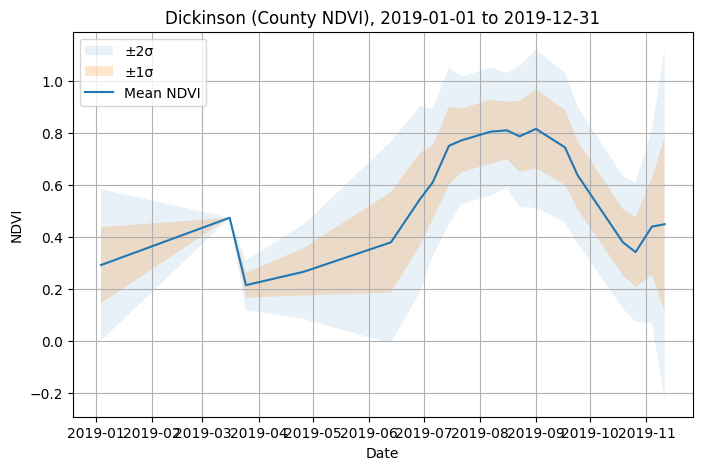


=== NDVI Time Series for Greene ===
+------------+-------------+-----------+---------+
| Date       |   Mean NDVI |   Std Dev |   Count |
+============+=============+===========+=========+
| 2019-01-04 |      0.2705 |    0.0755 |     200 |
+------------+-------------+-----------+---------+
| 2019-04-26 |      0.3079 |    0.1262 |     198 |
+------------+-------------+-----------+---------+
| 2019-06-13 |      0.4337 |    0.1809 |     201 |
+------------+-------------+-----------+---------+
| 2019-06-29 |      0.6315 |    0.1966 |     200 |
+------------+-------------+-----------+---------+
| 2019-07-15 |      0.8021 |    0.1387 |      66 |
+------------+-------------+-----------+---------+
| 2019-08-16 |      0.8407 |    0.0432 |      34 |
+------------+-------------+-----------+---------+
| 2019-09-01 |      0.841  |    0.0945 |      91 |
+------------+-------------+-----------+---------+
| 2019-09-17 |      0.7079 |    0.1386 |     186 |
+------------+-------------+-----------+-----

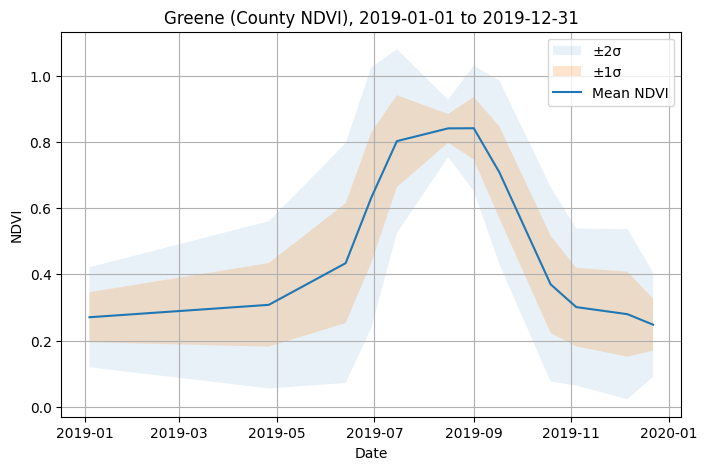


=== NDVI Time Series for Kossuth ===
+------------+-------------+-----------+---------+
| Date       |   Mean NDVI |   Std Dev |   Count |
+============+=============+===========+=========+
| 2019-01-04 |      0.2629 |    0.0743 |     190 |
+------------+-------------+-----------+---------+
| 2019-03-25 |      0.2376 |    0.0023 |       2 |
+------------+-------------+-----------+---------+
| 2019-04-26 |      0.2667 |    0.0852 |     200 |
+------------+-------------+-----------+---------+
| 2019-05-03 |      0.2459 |    0.0422 |       5 |
+------------+-------------+-----------+---------+
| 2019-05-12 |      0.3055 |    0.1184 |      96 |
+------------+-------------+-----------+---------+
| 2019-06-04 |      0.3924 |    0.1705 |       6 |
+------------+-------------+-----------+---------+
| 2019-06-13 |      0.3742 |    0.1539 |     200 |
+------------+-------------+-----------+---------+
| 2019-06-29 |      0.602  |    0.1647 |     200 |
+------------+-------------+-----------+----

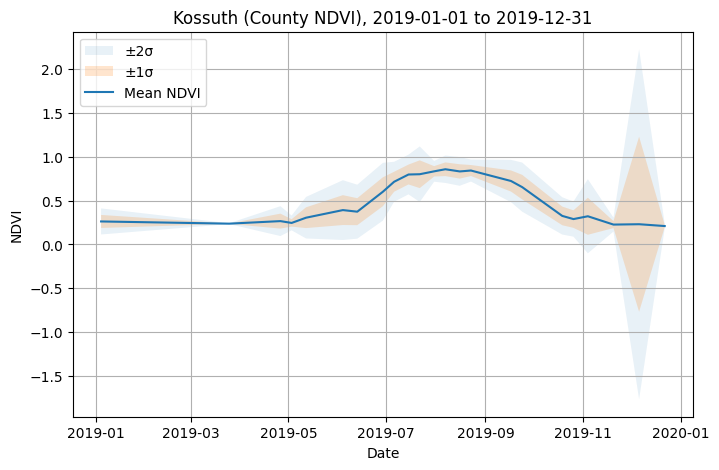

In [16]:
import ee
import math
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
from datetime import datetime


def main():
    # Example: Iowa (State FIPS = '19')
    state_fips = '19'
    print(f"Analyzing state FIPS={state_fips} ...")

    # 1) Get the smallest, median, and largest counties
    smallest, median, largest = get_county_spread(state_fips)

    # 2) For each of these counties, run the NDVI analysis
    for ctuple in [smallest, median, largest]:
        county_name, acreage = ctuple  # ctuple = (name, acreage)
        analyze_county_ndvi(
            county_name=county_name,
            state_fips=state_fips,
            start_date='2019-01-01',
            end_date='2019-12-31',
            num_points=250  # You can adjust the sampling density
        )


# --------------------------------------------------------------------------
# Run main (uncomment below if using in a script/Colab):
# --------------------------------------------------------------------------
if __name__ == "__main__":
    main()

+----------+---------------+-----------+
| Type     | County Name   | Acreage   |
+==========+===============+===========+
| Smallest | Dickinson     | 243,532   |
+----------+---------------+-----------+
| Median   | Greene        | 364,555   |
+----------+---------------+-----------+
| Largest  | Kossuth       | 622,547   |
+----------+---------------+-----------+
Smallest county: Dickinson

Processing crop: Corn (Code: 1)
+------------+-------------+-----------+---------+
| Date       |   Mean NDVI |   Std Dev |   Count |
+============+=============+===========+=========+
| 2019-01-04 |      0.2587 |    0.1126 |      11 |
+------------+-------------+-----------+---------+
| 2019-03-16 |      0.4725 |    0      |       1 |
+------------+-------------+-----------+---------+
| 2019-03-25 |      0.2173 |    0.0384 |      19 |
+------------+-------------+-----------+---------+
| 2019-04-26 |      0.2449 |    0.039  |      48 |
+------------+-------------+-----------+---------+
| 2019-06-

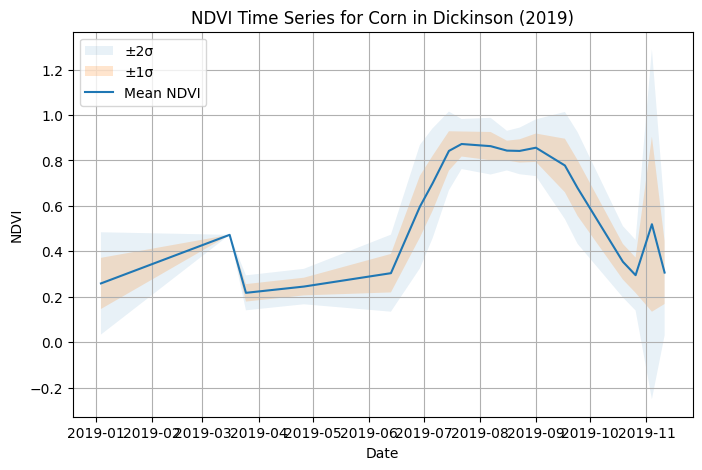


Processing crop: Soybeans (Code: 5)
+------------+-------------+-----------+---------+
| Date       |   Mean NDVI |   Std Dev |   Count |
+============+=============+===========+=========+
| 2019-01-04 |      0.2998 |    0.1448 |      12 |
+------------+-------------+-----------+---------+
| 2019-03-25 |      0.193  |    0.042  |      22 |
+------------+-------------+-----------+---------+
| 2019-04-26 |      0.2206 |    0.0255 |      41 |
+------------+-------------+-----------+---------+
| 2019-06-13 |      0.2596 |    0.0585 |      43 |
+------------+-------------+-----------+---------+
| 2019-06-29 |      0.3653 |    0.0702 |      43 |
+------------+-------------+-----------+---------+
| 2019-07-06 |      0.5256 |    0.0772 |      11 |
+------------+-------------+-----------+---------+
| 2019-07-15 |      0.6342 |    0.1013 |      26 |
+------------+-------------+-----------+---------+
| 2019-07-22 |      0.7205 |    0.0836 |      44 |
+------------+-------------+-----------+-----

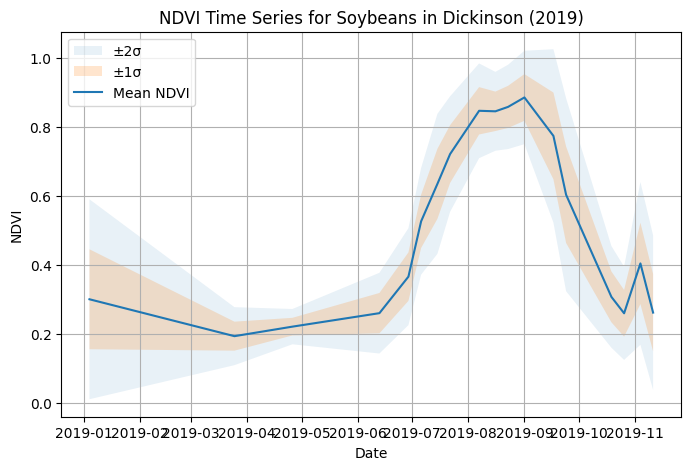


Processing crop: Deciduous Forest (Code: 141)
No NDVI data found for crop: Deciduous Forest. Skipping.

Processing crop: Grass/Pasture (Code: 176)
+------------+-------------+-----------+---------+
| Date       |   Mean NDVI |   Std Dev |   Count |
+============+=============+===========+=========+
| 2019-01-04 |      0.303  |    0.0052 |       2 |
+------------+-------------+-----------+---------+
| 2019-04-01 |      0.3145 |    0      |       1 |
+------------+-------------+-----------+---------+
| 2019-04-26 |      0.4157 |    0.2025 |       4 |
+------------+-------------+-----------+---------+
| 2019-06-13 |      0.7201 |    0.1058 |       7 |
+------------+-------------+-----------+---------+
| 2019-06-29 |      0.7226 |    0.0343 |       5 |
+------------+-------------+-----------+---------+
| 2019-07-06 |      0.8309 |    0.0157 |       2 |
+------------+-------------+-----------+---------+
| 2019-07-15 |      0.7495 |    0.0691 |       2 |
+------------+-------------+--------

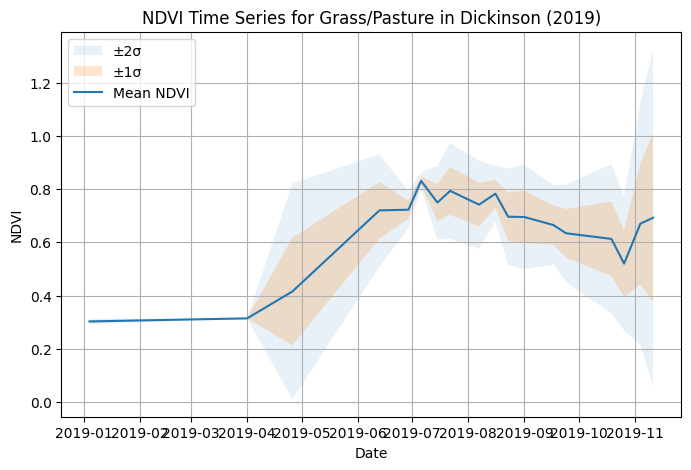


Processing crop: Developed/Open Space (Code: 121)
+------------+-------------+-----------+---------+
| Date       |   Mean NDVI |   Std Dev |   Count |
+============+=============+===========+=========+
| 2019-01-04 |      0.1934 |    0.0779 |       3 |
+------------+-------------+-----------+---------+
| 2019-03-25 |      0.2163 |    0.0482 |       3 |
+------------+-------------+-----------+---------+
| 2019-04-26 |      0.3387 |    0.1021 |       6 |
+------------+-------------+-----------+---------+
| 2019-06-13 |      0.5672 |    0.1671 |       7 |
+------------+-------------+-----------+---------+
| 2019-06-29 |      0.6413 |    0.1291 |       7 |
+------------+-------------+-----------+---------+
| 2019-07-06 |      0.7853 |    0      |       1 |
+------------+-------------+-----------+---------+
| 2019-07-15 |      0.7014 |    0.1088 |       3 |
+------------+-------------+-----------+---------+
| 2019-07-22 |      0.7368 |    0.155  |       8 |
+------------+-------------+---

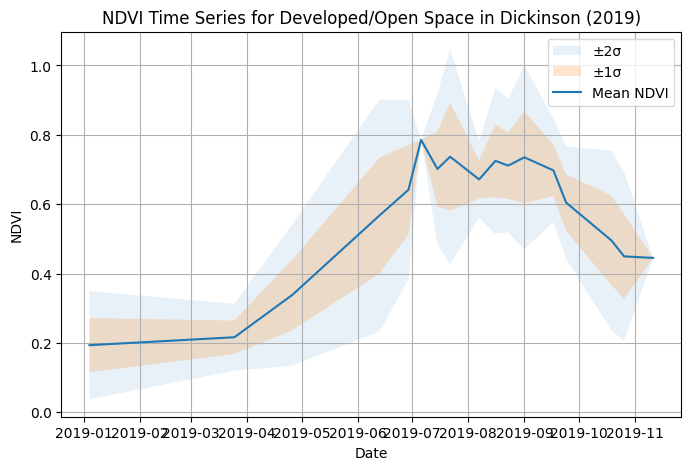

In [19]:
# -----------------------------
# Define the top 5 crops
# -----------------------------
top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space"
}

# -----------------------------
# Set state and get smallest county
# -----------------------------
state_fips = '19'  # Example: Iowa
smallest, median, largest = get_county_spread(state_fips)
smallest_county_name = smallest[0]
print("Smallest county:", smallest_county_name)

# -----------------------------
# Get county geometry and CDL image clipped to it
# -----------------------------
county_geom = get_county_geometry(state_fips, smallest_county_name)
cdl_county = ee.Image('USDA/NASS/CDL/2019').select('cropland').clip(county_geom)

# -----------------------------
# Create the Landsat NDVI collection for 2019
# -----------------------------
ndvi_collection = get_landsat_ndvi_collection('2019-01-01', '2019-12-31', county_geom)

# -----------------------------
# Loop over each of the top 5 crops
# -----------------------------
for crop_code, crop_name in top_5_crops.items():
    print(f"\nProcessing crop: {crop_name} (Code: {crop_code})")

    # Sample crop locations (using random sampling here; adjust num_points as needed)
    sample_fc = sample_crop_locations(
        cdl_image=cdl_county,
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=county_geom,
        num_points=250,   # adjust sample density as needed
        method='random'
    )

    # Extract the NDVI time series for the sampled points
    ndvi_ts = extract_ndvi_time_series(ndvi_collection, sample_fc)

    # Check if the NDVI time series is empty to avoid errors
    ts_size = ndvi_ts.size().getInfo()
    if ts_size == 0:
        print(f"No NDVI data found for crop: {crop_name}. Skipping.")
        continue  # skip processing for this crop

    # Aggregate the NDVI values by date (computing mean, std dev, count, etc.)
    agg_data = aggregate_ndvi_by_date(ndvi_ts)

    # Print the aggregated NDVI table for the crop
    if agg_data:
        from tabulate import tabulate
        table_rows = []
        for row in agg_data:
            table_rows.append({
                "Date": row['date'],
                "Mean NDVI": f"{row['mean_ndvi']:.4f}",
                "Std Dev": f"{row['std_dev']:.4f}",
                "Count": row['count']
            })
        print(tabulate(table_rows, headers="keys", tablefmt="grid"))
    else:
        print("No aggregated NDVI data available for this crop.")

    # Plot the NDVI time series with ±1σ and ±2σ bands
    title = f"NDVI Time Series for {crop_name} in {smallest_county_name} (2019)"
    plot_ndvi_time_series(agg_data, title=title)



### Task 2.3: Additional Analysis (optional but recommended)

Perform any additional analysis on the crops that you find interesting or useful for modeling. This is an open-ended exploration task to dive deeper into the data. Document your methodology and insights gained from any additional analysis. Visualizations and quantitative metrics are highly encouraged. This is your opportunity to freely explore the data and extract patterns that could help with crop modeling in Task 3. Be creative and have fun with the analysis!

*Any additional analysis that provides unique insights or utility for crop modeling may receive extra credit.* The depth and uniqueness of the exploration will determine the amount of extra credit awarded.

Some examples of analysis that could warrant extra credit:
- Extracting crop rotational patterns across multiple years
- Quantifying optimal temporal windows for distinguishing between crops (e.g. dormancy, emergence, harvest)
- Analyzing the utility of additional indices on top of NDVI
- Incorporating time series from sensors across the Landsat mission (e.g. L5/L7/L8/L9)

## Task 3: Crop Identification Modeling

Goal: Develop and validate a crop classification model using satellite imagery as input.

Overview:

1. Use the sampling script from Task 2 to generate training data for developing a classification model.
2. The model should predict the 5 major crops identified in Task 1, plus a 6th "other" class.
3. The input features should include data (raw and/or derived) from Landsat surface reflectance imagery.
5. Validate model performance by calculating precision, recall, F1 score metrics on a held-out test set.
6. Apply the model to full counties in Iowa and Illinois to create crop classification maps.
7. Visually compare the model output maps to the Cropland Data Layer for analysis.

### Task 3.1: Model Development

Develop a classification model to predict crop type using satellite imagery and temporal vegetation data as input features. The model should be trained on the sampled points from Task 2 and output predictions for the 5 major crops plus a "other" class.

Key Requirements:

- Use sampled crop points (or sampling script) from Task 2 as training data.
- You may want to include more samples for the model than what was created in Task 2.
- Input features must include, but are not limited to, Landsat surface reflectance imagery from the growing season.
- Incorporate temporal vegetation indices like NDVI time series.
- Output predictions for the 5 major crops identified in Task 1 plus an "other" class. This "other" class could be expanded into multiple classes if deemed useful.
- Document modeling methodology including:
  - Model type, input features, training approach
  - Any data preprocessing/augmentation
  - Tools and libraries used
  - Modeling can be fully in GEE or combine external tools like Scikit-learn, Tensorflow, etc.

Remember that ideally, we are attempting to build a model that does NOT require data across the entire year. Put another way, the less data our model needs about the growing season to make a good prediction about the crop type, the better!

If this proves challenging, start by using an entire year's worth of data for your model (like CDL). Achieving good performance with your classifier with a full year's worth of data will earn you full credit, and extra credit will be given to in-season prediction.

### Task 3.2: Model Testing

Validate the performance of the developed crop classification model using accuracy metrics calculated on a held-out test set. This test set can be created with the same sampling strategy from before, but should be created indepdently of the training and validation data (e.g. not be seen by the model at all before testing).

Key Requirements:

- Reserve 10-20% of the training data to hold out for testing.
- Calculate precision, recall and F1 score metrics on the test set.
- Generate a confusion matrix showing per-class accuracies and errors.
- Analyze the results - where does the model perform well or poorly?
- The validation script must enable testing on new unseen data.

Interpret what the results imply about the real-world viability of the model. It's okay if you don't think your model is anywhere nearly as good as CDL is. Identify areas for improvement and potential next steps to further improve performance. Finally, document insights gained from the validation process and analysis of the results.

### Task 3.3: Model Deployment

We're at the end, now it's time to see how our model does over an entire county! Apply the developed crop classification model to full counties to create prediction maps and visually compare against ground truth data.

Key Requirements:

- Script should take any county as an input and produce an output classification.
- Specifically generate output classification results for two counties: (1) Crawford County, Iowa (2) Grant County, Wisconsin. (NOTE we did not train at all in Wisconsin!)
- Run the model over all the pixels of each county.
- Output crop classification maps with predictions at 30 meter resolution.
- Visually compare the model outputs to the Cropland Data Layer (CDL).
- Document any data exports or external processing required.

If your model was built entirely in GEE (recommended), deployment should be straightforward. If your model however was built outside of GEE and you had to export lots of data to run your mode, you may need to ingest results back into GEE (if needed) for visualization and comparison.

Analyze similarities and differences between your model output and the CDL. Do they line up at all? Is your approach viable for real-world deployment? How do the results differ when looked at a much larger geographic scale compared to the test set?

## Tips
- Start small and iterate! Begin by testing workflows on small counties before expanding to the full two states. This will help identify any issues early.
- Leverage the vast data in GEE! The Cropland Data Layer and Landsat imagery on GEE provide a rich dataset. But feel free to incorporate any other relevant data sources available.
- Plan exporting data from GEE! For large regional analysis, you may need to batch export preprocessed data to your local environment for modeling.
- Store off computationally heavy intermediate results! you may want to store intermediate FeatureCollections and Images as GEE assets such that you do not have to dynamically re-create them every time.
- Documentation is key! Thoroughly document your methodology, thought process, experiments, and results. This transparency is important for full credit.
- Visualizations tell a story! Use insightful visuals like time series plots and comparison maps to showcase your findings.
- There are many valid approaches! This assignment is open-ended by design. There are many "correct" ways to analyze the data and build models.
- Ask questions early! Please reach out if you need any guidance or get stuck. I'm happy to provide clarification and nudges in the right direction.